# 0. Download dataset and set seed

In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

# print("Path to dataset files:", path)
# data_csv = path + "/Data/features_3_sec.csv"


Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Path to dataset files: /kaggle/input/gtzan-dataset-music-genre-classification


In [ ]:
# from pathlib import Path

# data_csv = Path("../data/features_3_sec.csv").resolve()
# print("Using data:", data_csv)

Using data: /data/features_3_sec.csv


In [46]:
import torch
import numpy as np
import pandas as pd
import random
import os
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def set_seed(seed=42):
	random.seed(seed)
	os.environ['PYTHONHASHSEED'] = str(seed)
	np.random.seed(seed)
	
	torch.manual_seed(seed)
	
	if torch.backends.mps.is_available():
		torch.mps.manual_seed(seed)
		os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

	if torch.cuda.is_available():
		torch.cuda.manual_seed(seed)
		torch.cuda.manual_seed_all(seed)
		torch.backends.cudnn.deterministic = True
		torch.backends.cudnn.benchmark = False

	try:
		torch.use_deterministic_algorithms(True)
	except RuntimeError:
		pass


def eval(y_true, y_pred):
	cf_matrix = confusion_matrix(y_true, y_pred)
	sns.set(rc = {'figure.figsize':(12,6)})
	sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues')
	print(classification_report(y_true,y_pred))

set_seed(42)


# 1. Reading features from dataset & Preprocessing

In [55]:
df = pd.read_csv(data_csv)
df.head()

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,...,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,...,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,...,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,...,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,...,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


In [56]:
df.describe()

,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,...,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var
count,9990.0,9990.000000,9990.000000,9990.000000,9.990000e+03,9990.000000,9.990000e+03,9990.000000,9.990000e+03,9990.000000,...,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000,9990.000000
mean,66149.0,0.379534,0.084876,0.130859,2.676388e-03,2199.219431,4.166727e+05,2241.385959,1.182711e+05,4566.076592,...,1.448240,49.988755,-4.198706,51.962753,0.739943,52.488851,-2.497306,54.973829,-0.917584,57.322614
std,0.0,0.090466,0.009637,0.068545,3.585628e-03,751.860611,4.349644e+05,543.854449,1.013505e+05,1642.065335,...,5.735149,34.442816,5.677379,36.400669,5.181313,38.177120,5.111799,41.585677,5.253243,46.444212
min,66149.0,0.107108,0.015345,0.000953,4.379535e-08,472.741636,8.118813e+02,499.162910,1.183520e+03,658.336276,...,-26.850016,1.325786,-27.809795,1.624544,-20.733809,3.437439,-27.448456,3.065302,-35.640659,0.282131
25%,66149.0,0.315698,0.079833,0.083782,6.145900e-04,1630.680158,1.231961e+05,1887.455790,4.876553e+04,3378.311110,...,-2.227478,29.584894,-7.951722,29.863448,-2.516638,29.636197,-5.734123,30.496412,-4.004475,30.011365
50%,66149.0,0.384741,0.085108,0.121253,1.491318e-03,2208.628236,2.650692e+05,2230.575595,8.996072e+04,4631.377892,...,1.461623,41.702393,-4.443021,42.393583,0.733772,41.831377,-2.702366,43.435253,-1.030939,44.332155
75%,66149.0,0.442443,0.091092,0.176328,3.130862e-03,2712.581884,5.624152e+05,2588.340505,1.585674e+05,5591.634521,...,5.149752,59.274619,-0.726945,61.676964,3.888734,62.033906,0.514246,65.328602,2.216603,68.210421
max,66149.0,0.749481,0.120964,0.442567,3.261522e-02,5432.534406,4.794119e+06,3708.147554,1.235143e+06,9487.446477,...,39.144405,683.932556,34.048843,529.363342,36.970322,629.729797,31.365425,1143.230591,34.212101,910.473206


In [57]:
df.shape

(9990, 60)

In [58]:
df.dtypes

,0
filename,object
length,int64
chroma_stft_mean,float64
chroma_stft_var,float64
rms_mean,float64
rms_var,float64
spectral_centroid_mean,float64
spectral_centroid_var,float64
spectral_bandwidth_mean,float64
spectral_bandwidth_var,float64


In [59]:
df = df.drop(labels="filename",axis=1)

In [60]:
X, y =  df.iloc[:,:-1], df.iloc[:,-1]

In [61]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

label2id = {label: int(id) for id, label in enumerate(encoder.classes_)}
id2label = {int(id): label for id, label in enumerate(encoder.classes_)}

print("Label to ID mapping:", label2id)
y = y_encoded

Label to ID mapping: {'blues': 0, 'classical': 1, 'country': 2, 'disco': 3, 'hiphop': 4, 'jazz': 5, 'metal': 6, 'pop': 7, 'reggae': 8, 'rock': 9}


In [62]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [63]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. Machine Learning

## 2.1. KNN

In [64]:
from sklearn.neighbors import KNeighborsClassifier

In [65]:
for k in range(1, 15):
	knn_cls = KNeighborsClassifier(n_neighbors=k, weights='distance')
	knn_cls.fit(X_train,y_train)
	y_pred=knn_cls.predict(X_test)
	print(f"k = {k}")
	print("Training set score: {:.3f}".format(knn_cls.score(X_train, y_train)))
	print("Test set score: {:.3f}".format(knn_cls.score(X_test, y_test)))

k = 1
Training set score: 0.999
Test set score: 0.905
k = 2
Training set score: 0.999
Test set score: 0.905
k = 3
Training set score: 0.999
Test set score: 0.903
k = 4
Training set score: 0.999
Test set score: 0.904
k = 5
Training set score: 0.999
Test set score: 0.897
k = 6
Training set score: 0.999
Test set score: 0.897
k = 7
Training set score: 0.999
Test set score: 0.892
k = 8
Training set score: 0.999
Test set score: 0.890
k = 9
Training set score: 0.999
Test set score: 0.883
k = 10
Training set score: 0.999
Test set score: 0.879
k = 11
Training set score: 0.999
Test set score: 0.870
k = 12
Training set score: 0.999
Test set score: 0.868
k = 13
Training set score: 0.999
Test set score: 0.858
k = 14
Training set score: 0.999
Test set score: 0.857


              precision    recall  f1-score   support

           0       0.94      0.91      0.92       319
           1       0.92      0.93      0.92       308
           2       0.86      0.80      0.83       286
           3       0.86      0.91      0.89       301
           4       0.95      0.94      0.94       311
           5       0.87      0.90      0.88       286
           6       0.98      0.96      0.97       303
           7       0.90      0.94      0.92       267
           8       0.86      0.93      0.89       316
           9       0.91      0.84      0.88       300

    accuracy                           0.90      2997
   macro avg       0.90      0.90      0.90      2997
weighted avg       0.91      0.90      0.90      2997



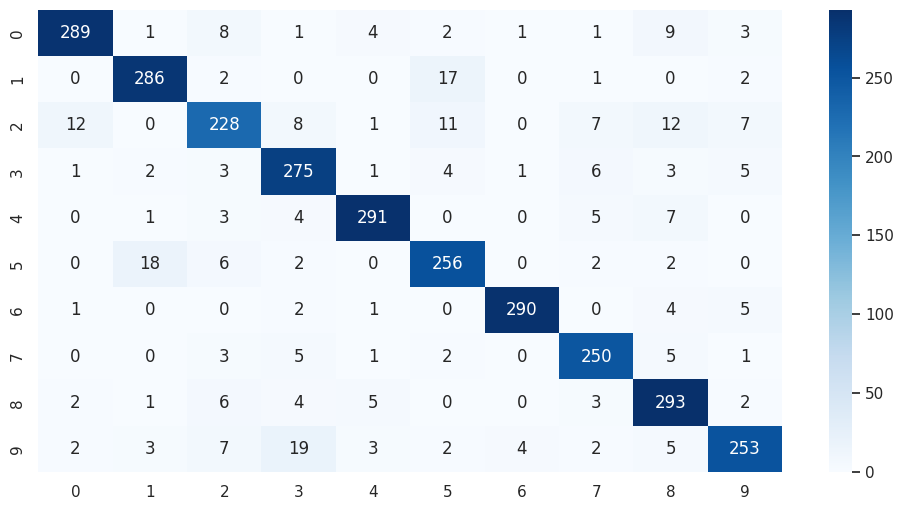

In [66]:
# Use k = 1 as it achieved the best result
knn_cls = KNeighborsClassifier(n_neighbors=1, weights='distance')
knn_cls.fit(X_train,y_train)
y_pred=knn_cls.predict(X_test)
eval(y_test, y_pred)

## 2.2. SVM

In [67]:
from sklearn.svm import SVC

Training set score: 0.913
Test set score: 0.853
              precision    recall  f1-score   support

           0       0.87      0.87      0.87       319
           1       0.85      0.98      0.91       308
           2       0.79      0.79      0.79       286
           3       0.81      0.80      0.80       301
           4       0.93      0.84      0.88       311
           5       0.84      0.85      0.85       286
           6       0.89      0.92      0.91       303
           7       0.87      0.90      0.89       267
           8       0.88      0.87      0.88       316
           9       0.78      0.70      0.74       300

    accuracy                           0.85      2997
   macro avg       0.85      0.85      0.85      2997
weighted avg       0.85      0.85      0.85      2997



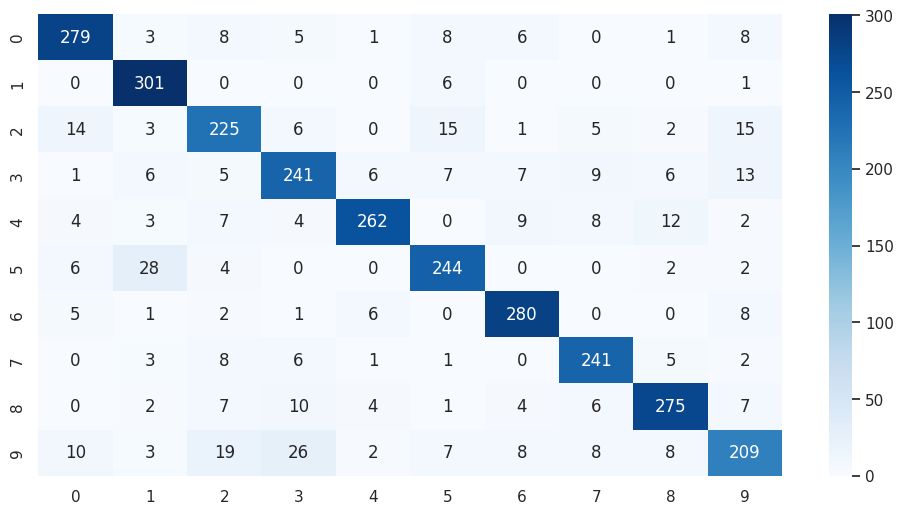

In [68]:
svm_cls = SVC(kernel='rbf')
svm_cls.fit(X_train, y_train)

print("Training set score: {:.3f}".format(svm_cls.score(X_train, y_train)))
print("Test set score: {:.3f}".format(svm_cls.score(X_test, y_test)))

y_pred = svm_cls.predict(X_test)
eval(y_test, y_pred)

Training set score: 0.809
Test set score: 0.763
              precision    recall  f1-score   support

           0       0.73      0.81      0.76       319
           1       0.90      0.95      0.92       308
           2       0.67      0.67      0.67       286
           3       0.66      0.68      0.67       301
           4       0.76      0.76      0.76       311
           5       0.84      0.84      0.84       286
           6       0.86      0.86      0.86       303
           7       0.80      0.88      0.84       267
           8       0.78      0.68      0.73       316
           9       0.63      0.52      0.57       300

    accuracy                           0.76      2997
   macro avg       0.76      0.76      0.76      2997
weighted avg       0.76      0.76      0.76      2997



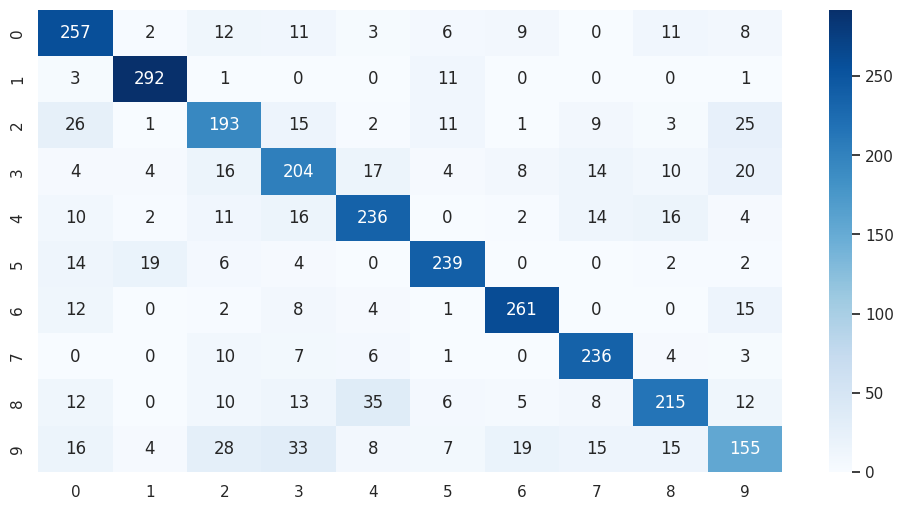

In [69]:
svm_cls = SVC(kernel='linear')
svm_cls.fit(X_train, y_train)

print("Training set score: {:.3f}".format(svm_cls.score(X_train, y_train)))
print("Test set score: {:.3f}".format(svm_cls.score(X_test, y_test)))

y_pred = svm_cls.predict(X_test)
eval(y_test, y_pred)

Training set score: 0.876
Test set score: 0.807
              precision    recall  f1-score   support

           0       0.92      0.72      0.81       319
           1       0.93      0.94      0.93       308
           2       0.53      0.86      0.65       286
           3       0.69      0.81      0.74       301
           4       0.94      0.77      0.85       311
           5       0.86      0.87      0.87       286
           6       0.91      0.86      0.89       303
           7       0.92      0.85      0.88       267
           8       0.87      0.78      0.82       316
           9       0.74      0.63      0.68       300

    accuracy                           0.81      2997
   macro avg       0.83      0.81      0.81      2997
weighted avg       0.83      0.81      0.81      2997



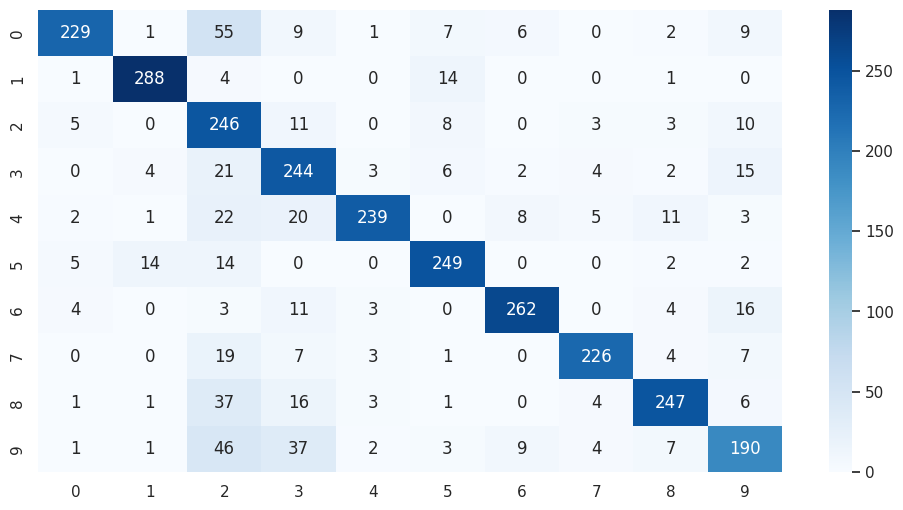

In [70]:
svm_cls = SVC(kernel='poly')
svm_cls.fit(X_train, y_train)

print("Training set score: {:.3f}".format(svm_cls.score(X_train, y_train)))
print("Test set score: {:.3f}".format(svm_cls.score(X_test, y_test)))

y_pred = svm_cls.predict(X_test)
eval(y_test, y_pred)

Training set score: 0.501
Test set score: 0.512
              precision    recall  f1-score   support

           0       0.50      0.50      0.50       319
           1       0.67      0.84      0.75       308
           2       0.49      0.43      0.46       286
           3       0.32      0.32      0.32       301
           4       0.39      0.35      0.37       311
           5       0.69      0.57      0.62       286
           6       0.63      0.79      0.70       303
           7       0.41      0.72      0.52       267
           8       0.56      0.36      0.44       316
           9       0.45      0.27      0.34       300

    accuracy                           0.51      2997
   macro avg       0.51      0.51      0.50      2997
weighted avg       0.51      0.51      0.50      2997



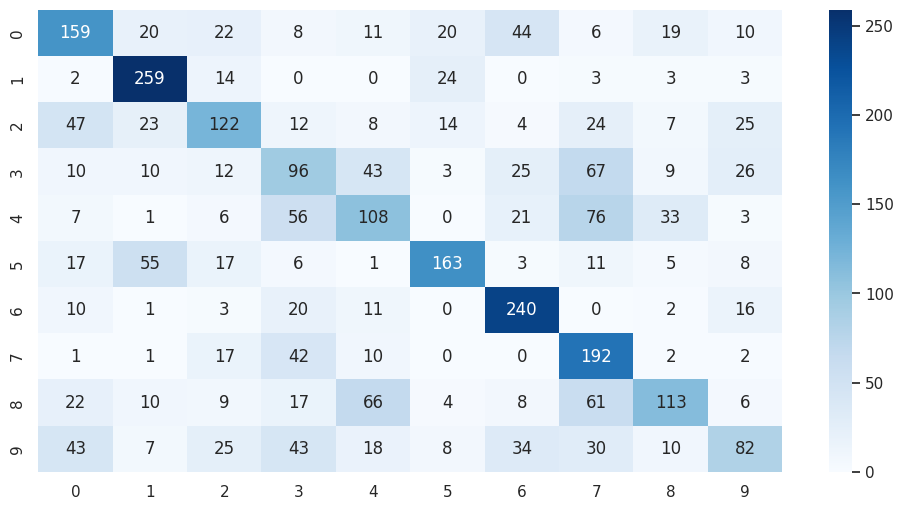

In [71]:
svm_cls = SVC(kernel='sigmoid')
svm_cls.fit(X_train, y_train)

print("Training set score: {:.3f}".format(svm_cls.score(X_train, y_train)))
print("Test set score: {:.3f}".format(svm_cls.score(X_test, y_test)))

y_pred = svm_cls.predict(X_test)
eval(y_test, y_pred)

## 2.3. XGBoost

Training set score: 0.999
Test set score: 0.897
              precision    recall  f1-score   support

           0       0.91      0.85      0.88       319
           1       0.93      0.97      0.95       308
           2       0.80      0.86      0.83       286
           3       0.86      0.87      0.87       301
           4       0.94      0.92      0.93       311
           5       0.89      0.92      0.90       286
           6       0.93      0.93      0.93       303
           7       0.91      0.95      0.93       267
           8       0.92      0.89      0.90       316
           9       0.87      0.82      0.84       300

    accuracy                           0.90      2997
   macro avg       0.90      0.90      0.90      2997
weighted avg       0.90      0.90      0.90      2997



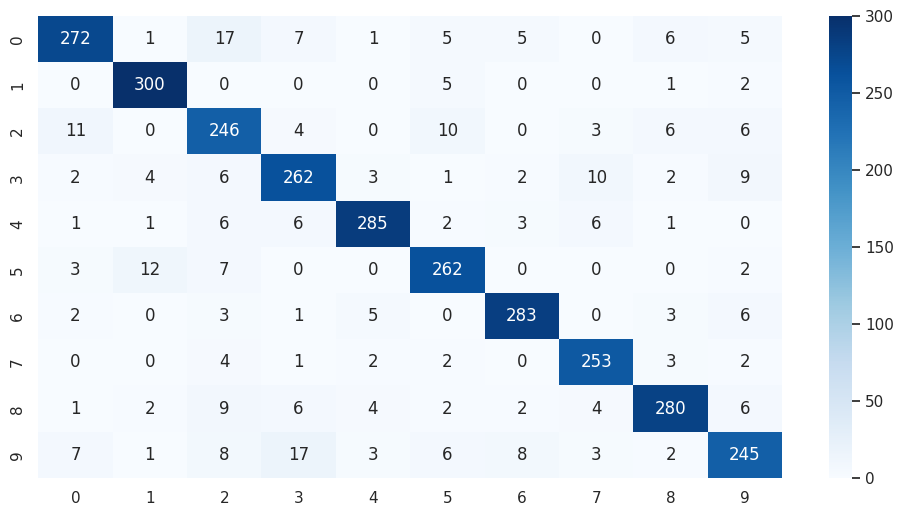

In [72]:
import xgboost
xgb_cls = xgboost.XGBClassifier()
xgb_cls.fit(X_train, y_train)

print("Training set score: {:.3f}".format(xgb_cls.score(X_train, y_train)))
print("Test set score: {:.3f}".format(xgb_cls.score(X_test, y_test)))

y_pred = xgb_cls.predict(X_test)
eval(y_test, y_pred)

## 2.4. LightGBM

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training set score: 0.999


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test set score: 0.908


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.92      0.89      0.90       319
           1       0.95      0.97      0.96       308
           2       0.82      0.87      0.84       286
           3       0.87      0.89      0.88       301
           4       0.96      0.91      0.93       311
           5       0.90      0.93      0.91       286
           6       0.95      0.95      0.95       303
           7       0.92      0.97      0.94       267
           8       0.92      0.91      0.91       316
           9       0.88      0.81      0.84       300

    accuracy                           0.91      2997
   macro avg       0.91      0.91      0.91      2997
weighted avg       0.91      0.91      0.91      2997



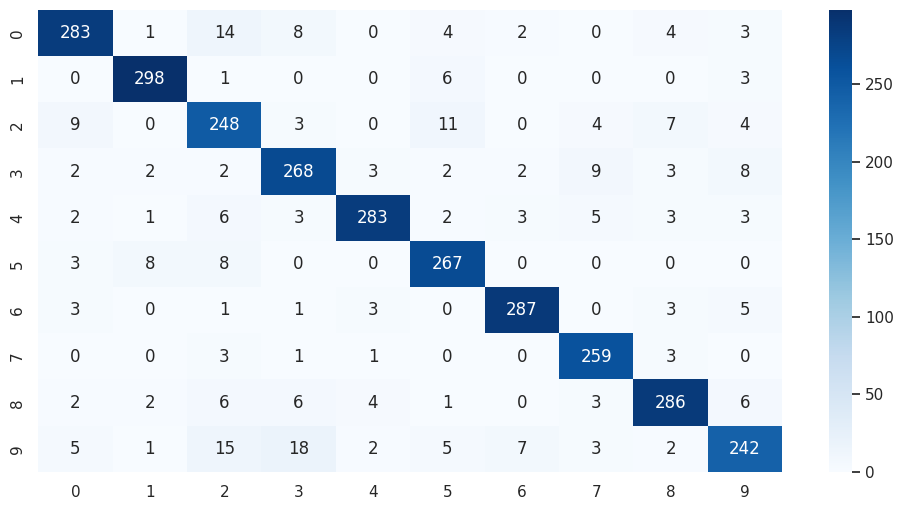

In [73]:
import lightgbm
lgb_cls = lightgbm.LGBMClassifier(verbose=-1)
lgb_cls.fit(X_train, y_train)

print("Training set score: {:.3f}".format(lgb_cls.score(X_train, y_train)))
print("Test set score: {:.3f}".format(lgb_cls.score(X_test, y_test)))

y_pred = lgb_cls.predict(X_test)
eval(y_test, y_pred)

## 2.5. Ensemble

### 2.5.1. Hard Voting

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training set score: 0.999


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test set score: 0.915


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.91      0.93      0.92       319
           1       0.91      0.98      0.95       308
           2       0.82      0.87      0.85       286
           3       0.86      0.92      0.89       301
           4       0.96      0.94      0.95       311
           5       0.93      0.91      0.92       286
           6       0.96      0.95      0.95       303
           7       0.93      0.96      0.95       267
           8       0.95      0.89      0.92       316
           9       0.92      0.78      0.84       300

    accuracy                           0.91      2997
   macro avg       0.92      0.91      0.91      2997
weighted avg       0.92      0.91      0.91      2997



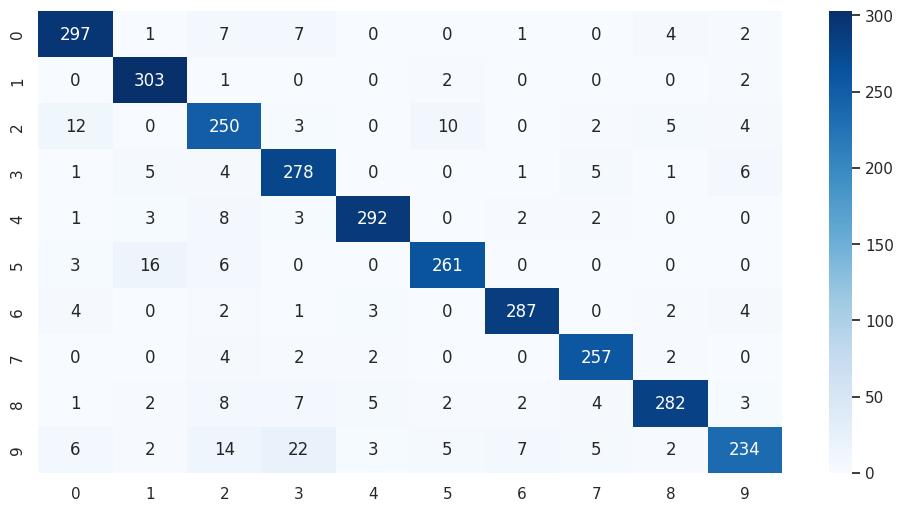

In [74]:
from sklearn.ensemble import VotingClassifier

knn_cls = KNeighborsClassifier(n_neighbors=1, weights='distance')
svm_cls = SVC(kernel='rbf')
xgb_cls = xgboost.XGBClassifier()
lgb_cls = lightgbm.LGBMClassifier(verbose=-1)

voting_clf = VotingClassifier(
    estimators=[
        ('knn', knn_cls),
        ('svm', svm_cls),
        ('xgb', xgb_cls),
        ('lgb', lgb_cls)
    ],
    voting='hard'
)

voting_clf.fit(X_train, y_train)

print("Training set score: {:.3f}".format(voting_clf.score(X_train, y_train)))
print("Test set score: {:.3f}".format(voting_clf.score(X_test, y_test)))

y_pred = voting_clf.predict(X_test)
eval(y_test, y_pred)

### 2.5.2. Soft Voting

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Training set score: 0.999


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Test set score: 0.931


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       0.95      0.92      0.93       319
           1       0.94      0.98      0.96       308
           2       0.89      0.89      0.89       286
           3       0.88      0.93      0.90       301
           4       0.96      0.95      0.95       311
           5       0.93      0.93      0.93       286
           6       0.96      0.96      0.96       303
           7       0.93      0.99      0.96       267
           8       0.93      0.94      0.94       316
           9       0.94      0.84      0.89       300

    accuracy                           0.93      2997
   macro avg       0.93      0.93      0.93      2997
weighted avg       0.93      0.93      0.93      2997



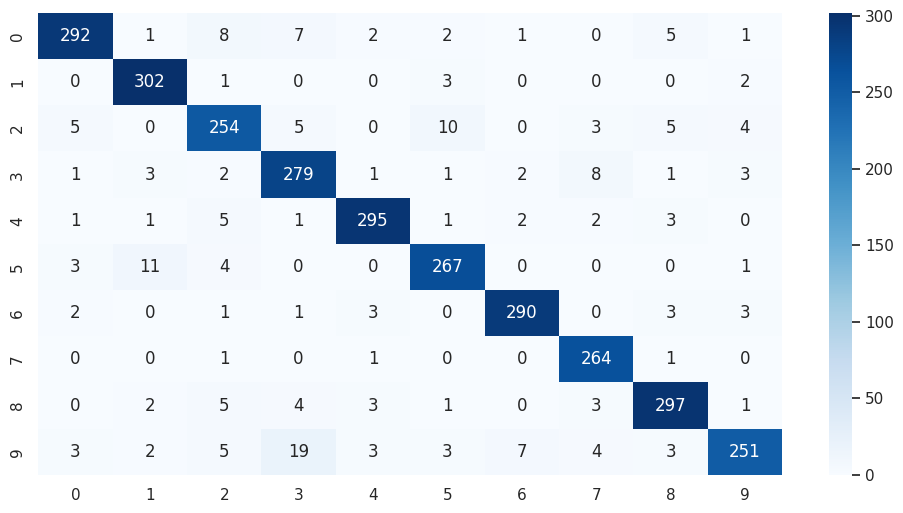

In [75]:
from sklearn.ensemble import VotingClassifier

knn_cls = KNeighborsClassifier(n_neighbors=1, weights='distance')
svm_cls = SVC(kernel='rbf', probability=True)
xgb_cls = xgboost.XGBClassifier()
lgb_cls = lightgbm.LGBMClassifier(verbose=-1)

# weight based on their accuracy
custom_weights=[0.905, 0.853, 0.897, 0.908]

voting_clf = VotingClassifier(
    estimators=[
        ('knn', knn_cls),
        ('svm', svm_cls),
        ('xgb', xgb_cls),
        ('lgb', lgb_cls)
    ],
    voting='soft',
    weights=custom_weights
)

voting_clf.fit(X_train, y_train)

print("Training set score: {:.3f}".format(voting_clf.score(X_train, y_train)))
print("Test set score: {:.3f}".format(voting_clf.score(X_test, y_test)))

y_pred = voting_clf.predict(X_test)
eval(y_test, y_pred)

Utilizing Soft Voting with weights assigned based on the individual accuracy of each constituent model typically yields the highest overall ensemble performance.

# 3. Deep learning (MLP)

In [76]:
import numpy as np
import torch
from torch import nn, optim
from torch.functional import F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

In [77]:
class MLP(nn.Module):
    def __init__(self, input_size, num_classes=10):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()

        # Layer 1
        self.fc1 = nn.Linear(input_size, 512)
        self.bn1 = nn.BatchNorm1d(512)

        # Layer 2
        self.fc2 = nn.Linear(512, 256)
        self.bn2 = nn.BatchNorm1d(256)

        # Layer 3
        self.fc3 = nn.Linear(256, 128)
        self.bn3 = nn.BatchNorm1d(128)

        # Output Layer
        self.fc_out = nn.Linear(128, num_classes)

        self.dropout = nn.Dropout(0.3)
        self.silu = nn.SiLU()

    def forward(self, x):
        x = self.flatten(x)

        # Block 1
        x = self.silu(self.bn1(self.fc1(x)))
        x = self.dropout(x)

        # Block 2
        x = self.silu(self.bn2(self.fc2(x)))
        x = self.dropout(x)

        # Block 3
        x = self.silu(self.bn3(self.fc3(x)))

        x = self.fc_out(x)
        return x

In [ ]:
device = 'mps' if torch.cuda.is_available() else 'cpu'
input_size = X_train.shape[1]
num_epochs = 500

model = MLP(input_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [80]:
train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32).to(device),
    torch.tensor(y_train, dtype=torch.long).to(device)
)

val_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32).to(device),
    torch.tensor(y_test, dtype=torch.long).to(device)
)

batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [81]:
num_epochs = 500
step = 0

for epoch in range(num_epochs):
    model.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs.float())
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        if step % 100 == 0:
            print(f"Step {step}, Train Loss: {loss.item():.4f}")
        step += 1

    if 'scheduler' in locals():
        scheduler.step()

    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs.float())
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    if (epoch + 1) % 50 == 0 or epoch == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1}/{num_epochs}, Accuracy: {100 * correct / total:.2f}%, LR: {current_lr:.6f}")

Step 0, Train Loss: 2.3939
Epoch 1/500, Accuracy: 64.76%, LR: 0.001000
Step 100, Train Loss: 0.7457
Step 200, Train Loss: 0.5041
Step 300, Train Loss: 0.4133
Step 400, Train Loss: 0.3445
Step 500, Train Loss: 0.3167
Step 600, Train Loss: 0.2427
Step 700, Train Loss: 0.2102
Step 800, Train Loss: 0.1800
Step 900, Train Loss: 0.1706
Step 1000, Train Loss: 0.1297
Step 1100, Train Loss: 0.1283
Step 1200, Train Loss: 0.1309
Step 1300, Train Loss: 0.1640
Epoch 50/500, Accuracy: 91.49%, LR: 0.000976
Step 1400, Train Loss: 0.0587
Step 1500, Train Loss: 0.0886
Step 1600, Train Loss: 0.0935
Step 1700, Train Loss: 0.0751
Step 1800, Train Loss: 0.0589
Step 1900, Train Loss: 0.0830
Step 2000, Train Loss: 0.0926
Step 2100, Train Loss: 0.0830
Step 2200, Train Loss: 0.0655
Step 2300, Train Loss: 0.0870
Step 2400, Train Loss: 0.0491
Step 2500, Train Loss: 0.0382
Step 2600, Train Loss: 0.0279
Step 2700, Train Loss: 0.0497
Epoch 100/500, Accuracy: 92.43%, LR: 0.000905
Step 2800, Train Loss: 0.0441
Step 29

Training set score: 0.999
Test set score: 0.940
              precision    recall  f1-score   support

           0       0.94      0.95      0.94       319
           1       0.94      0.98      0.96       308
           2       0.87      0.92      0.89       286
           3       0.94      0.93      0.93       301
           4       0.96      0.94      0.95       311
           5       0.92      0.93      0.92       286
           6       0.97      0.96      0.97       303
           7       0.96      0.97      0.96       267
           8       0.96      0.95      0.95       316
           9       0.94      0.88      0.91       300

    accuracy                           0.94      2997
   macro avg       0.94      0.94      0.94      2997
weighted avg       0.94      0.94      0.94      2997



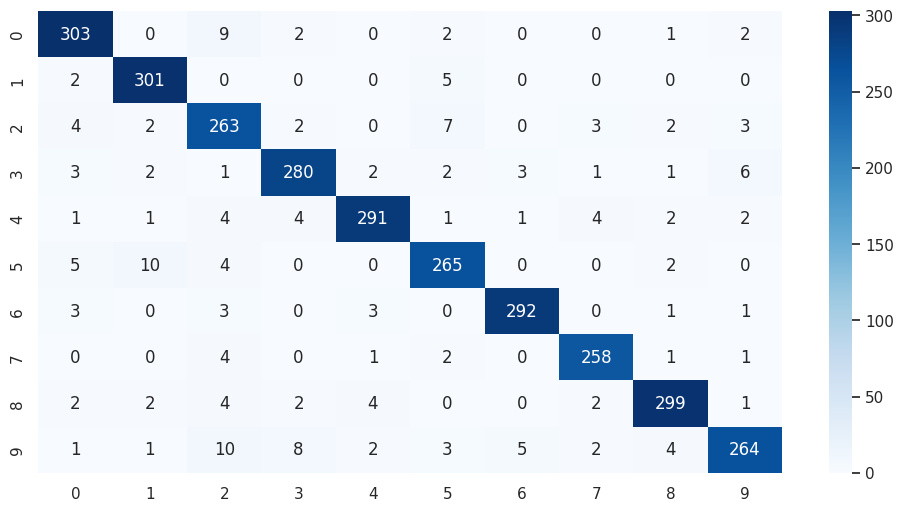

In [82]:
def calculate_accuracy(loader, model):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs.float())
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

train_accuracy = calculate_accuracy(train_loader, model)
test_accuracy = calculate_accuracy(val_loader, model)

print("Training set score: {:.3f}".format(train_accuracy))
print("Test set score: {:.3f}".format(test_accuracy))

model.eval()
y_preds = []
y_true = []
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs.float())
        _, predicted = outputs.max(1)
        y_preds.extend(predicted.cpu().numpy())
        y_true.extend(labels.cpu().numpy())


eval(y_true, y_preds)